In [15]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import cv2
import torch

from grid_pattern_formation.evals.core import build_eval_context, get_cached_ratemaps
from grid_pattern_formation.evals.analysis_connectivity import _compute_phase_order
from grid_pattern_formation.evals.analysis_core import compute_grid_scores

%matplotlib inline
plt.rcParams.update({'figure.dpi': 150, 'font.size': 10, 'figure.facecolor': 'white'})

In [16]:
ctx = build_eval_context(
    checkpoint_path='../checkpoints/baseline_final.pth',
    config_path='../configs/replicate_baseline.yaml',
    results_root='../results/baseline_diagnostic',
)

RES = 50
N_AVG = 100
Ng = 4096
n = int(np.sqrt(Ng))

act, rm, g, pos = get_cached_ratemaps(ctx, res=RES, n_avg=N_AVG, ng=Ng)
order, phases = _compute_phase_order(ctx, rm, RES)
scores = compute_grid_scores(ctx)
score60 = scores['score_60']

# Sorted versions
act_sorted = act[order]
score60_sorted = score60[order]
phases_sorted = phases[:, order]

J = ctx.model.RNN.weight_hh_l0.detach().cpu().numpy().T
J_sorted = J[order][:, order]

Grid scores: 100%|██████████| 4096/4096 [00:12<00:00, 339.14it/s]


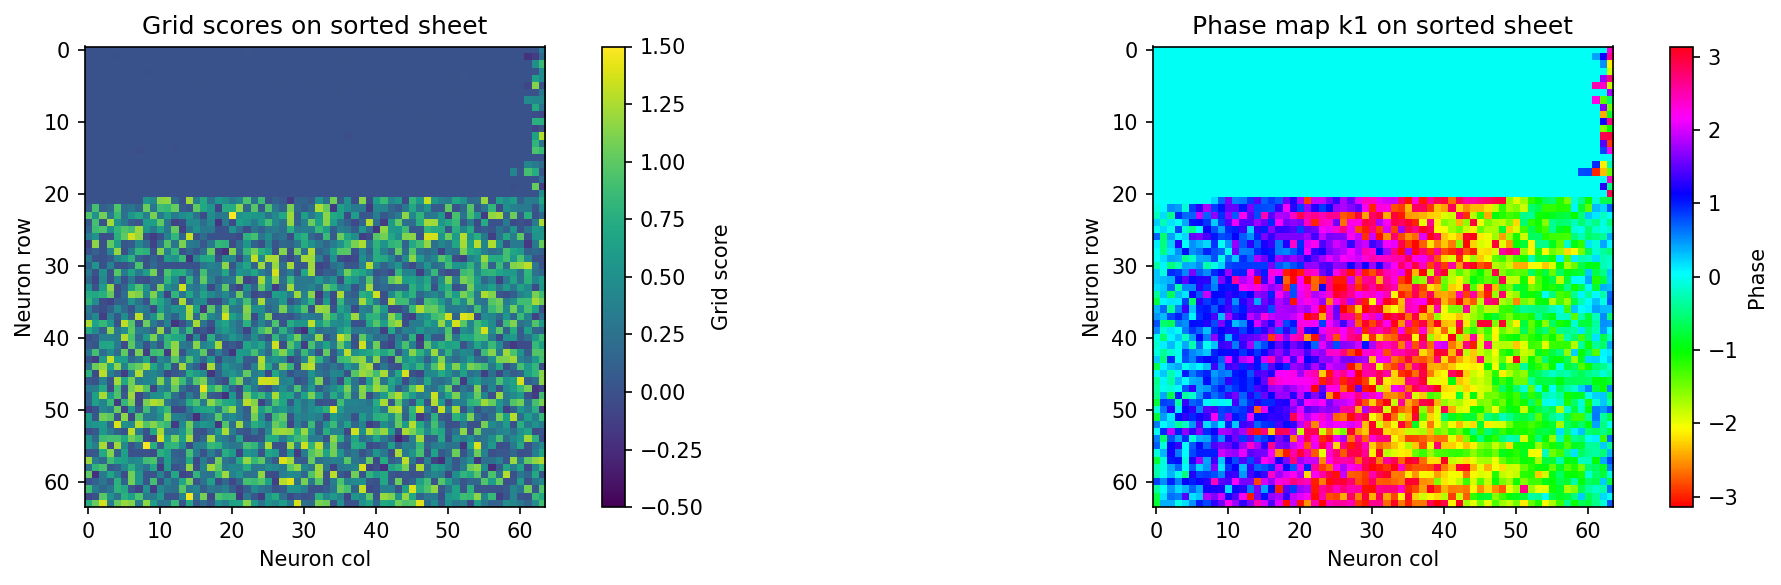

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

# Grid score
ax = axes[0]
im = ax.imshow(score60_sorted.reshape(n, n), cmap='viridis', vmin=-0.5, vmax=1.5)
plt.colorbar(im, ax=ax, label='Grid score')
ax.set_title('Grid scores on sorted sheet')
ax.set_xlabel('Neuron col'); ax.set_ylabel('Neuron row')

# Phase map
ax = axes[1]
im = ax.imshow(phases_sorted[0].reshape(n, n), cmap='hsv', vmin=-np.pi, vmax=np.pi)
plt.colorbar(im, ax=ax, label='Phase')
ax.set_title('Phase map k1 on sorted sheet')
ax.set_xlabel('Neuron col'); ax.set_ylabel('Neuron row')

plt.tight_layout()
plt.show()

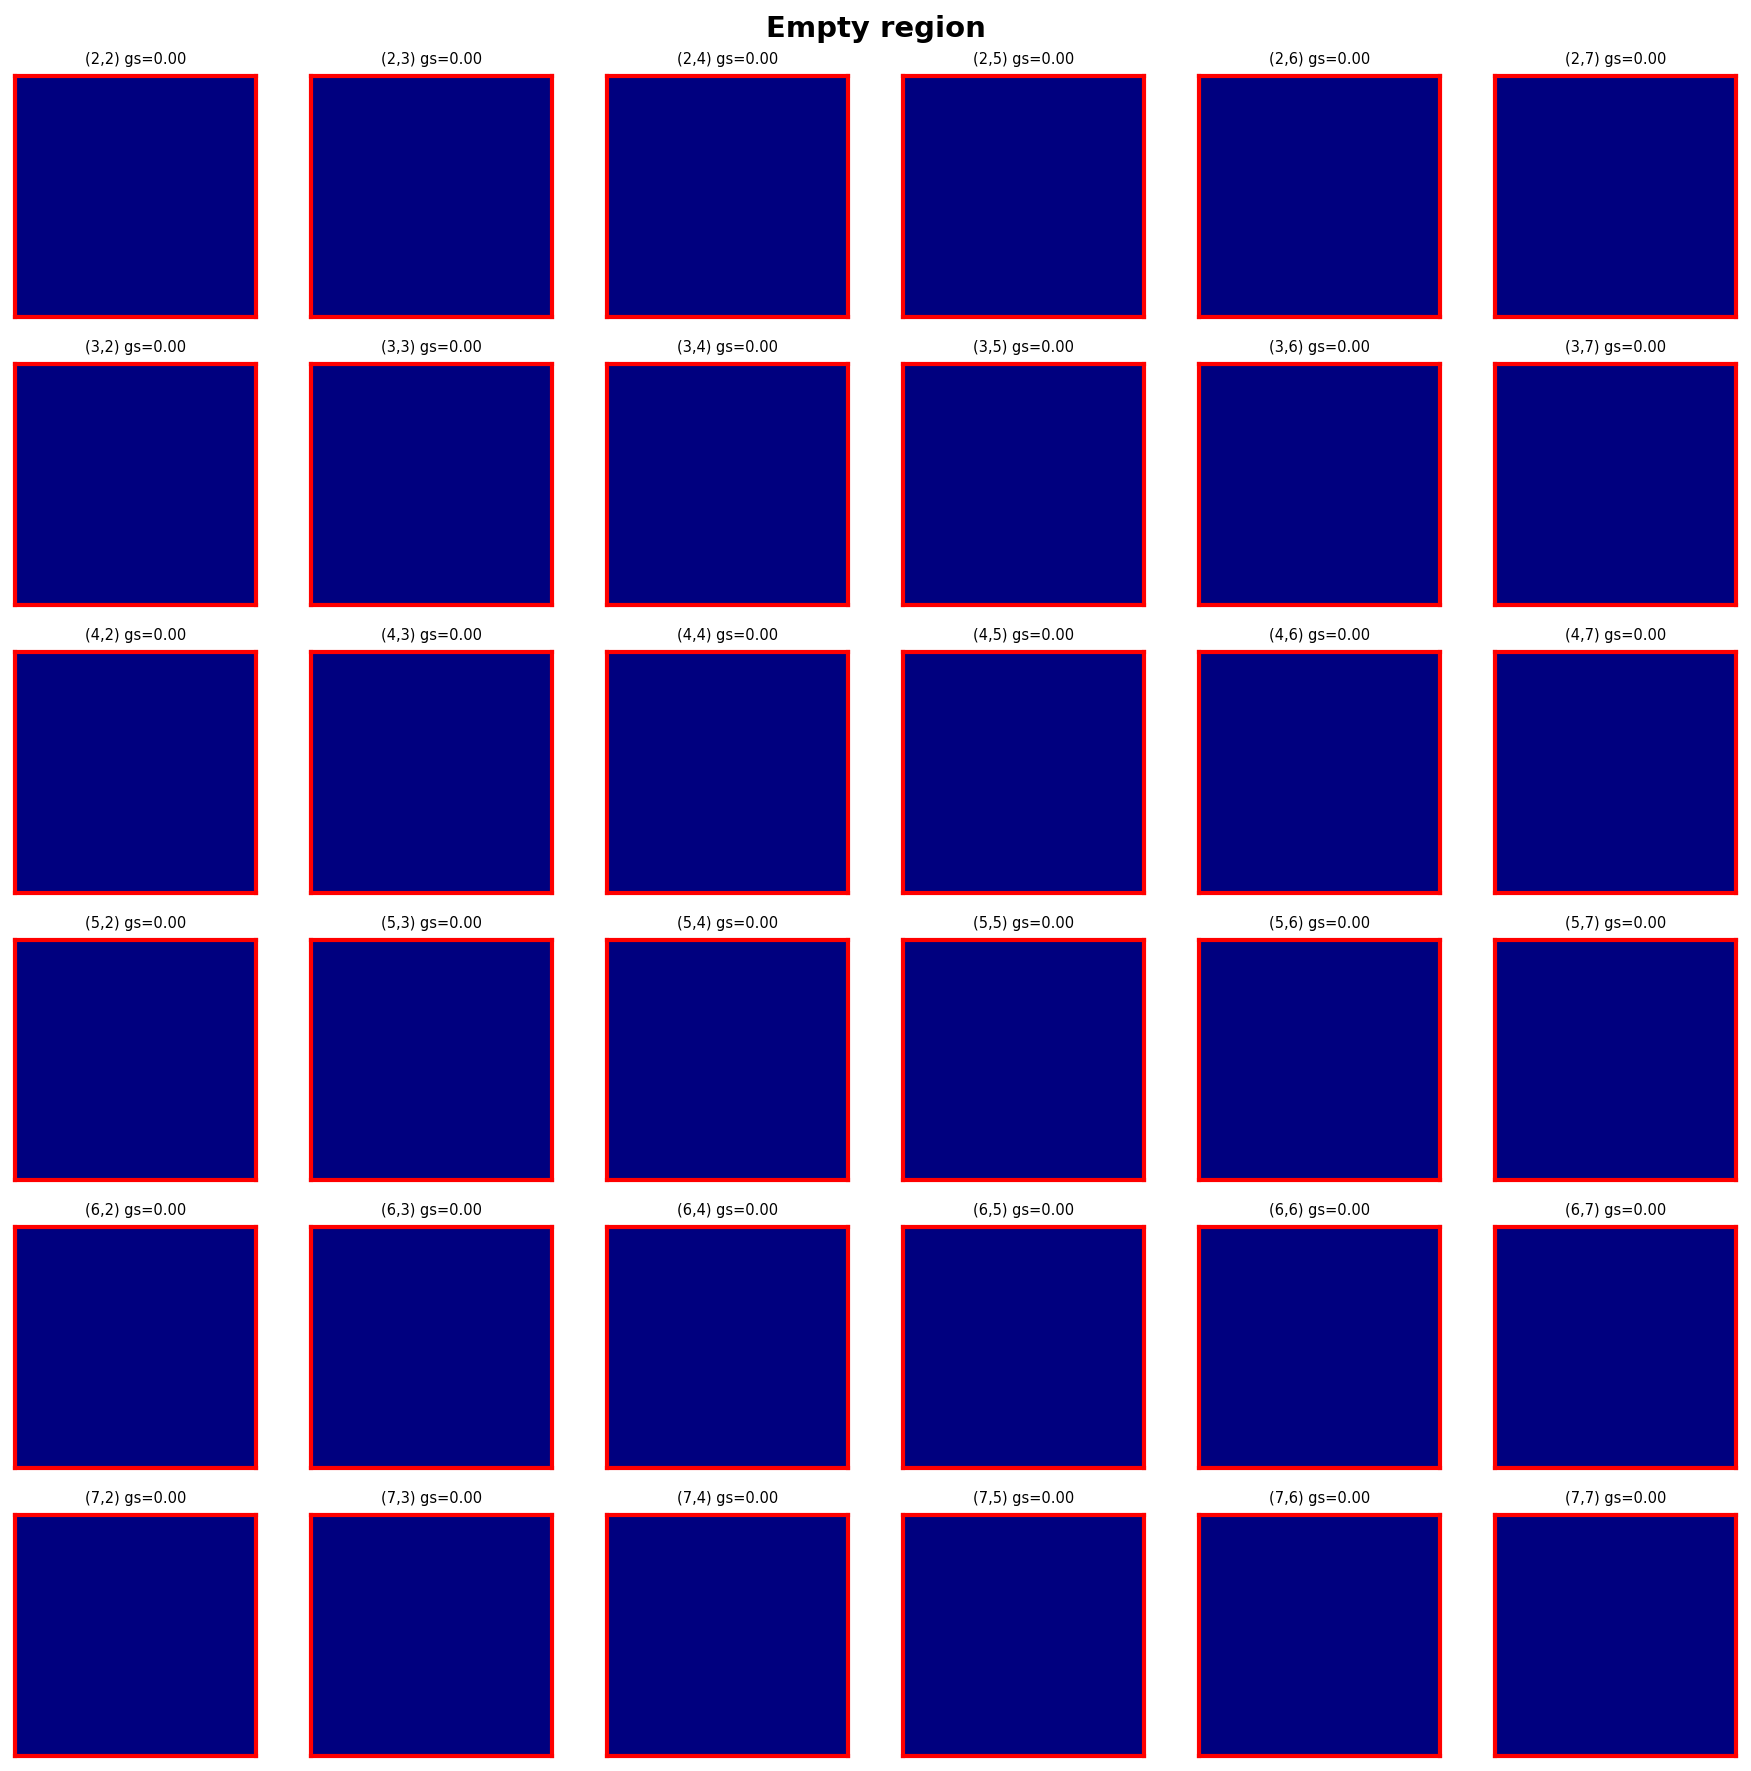

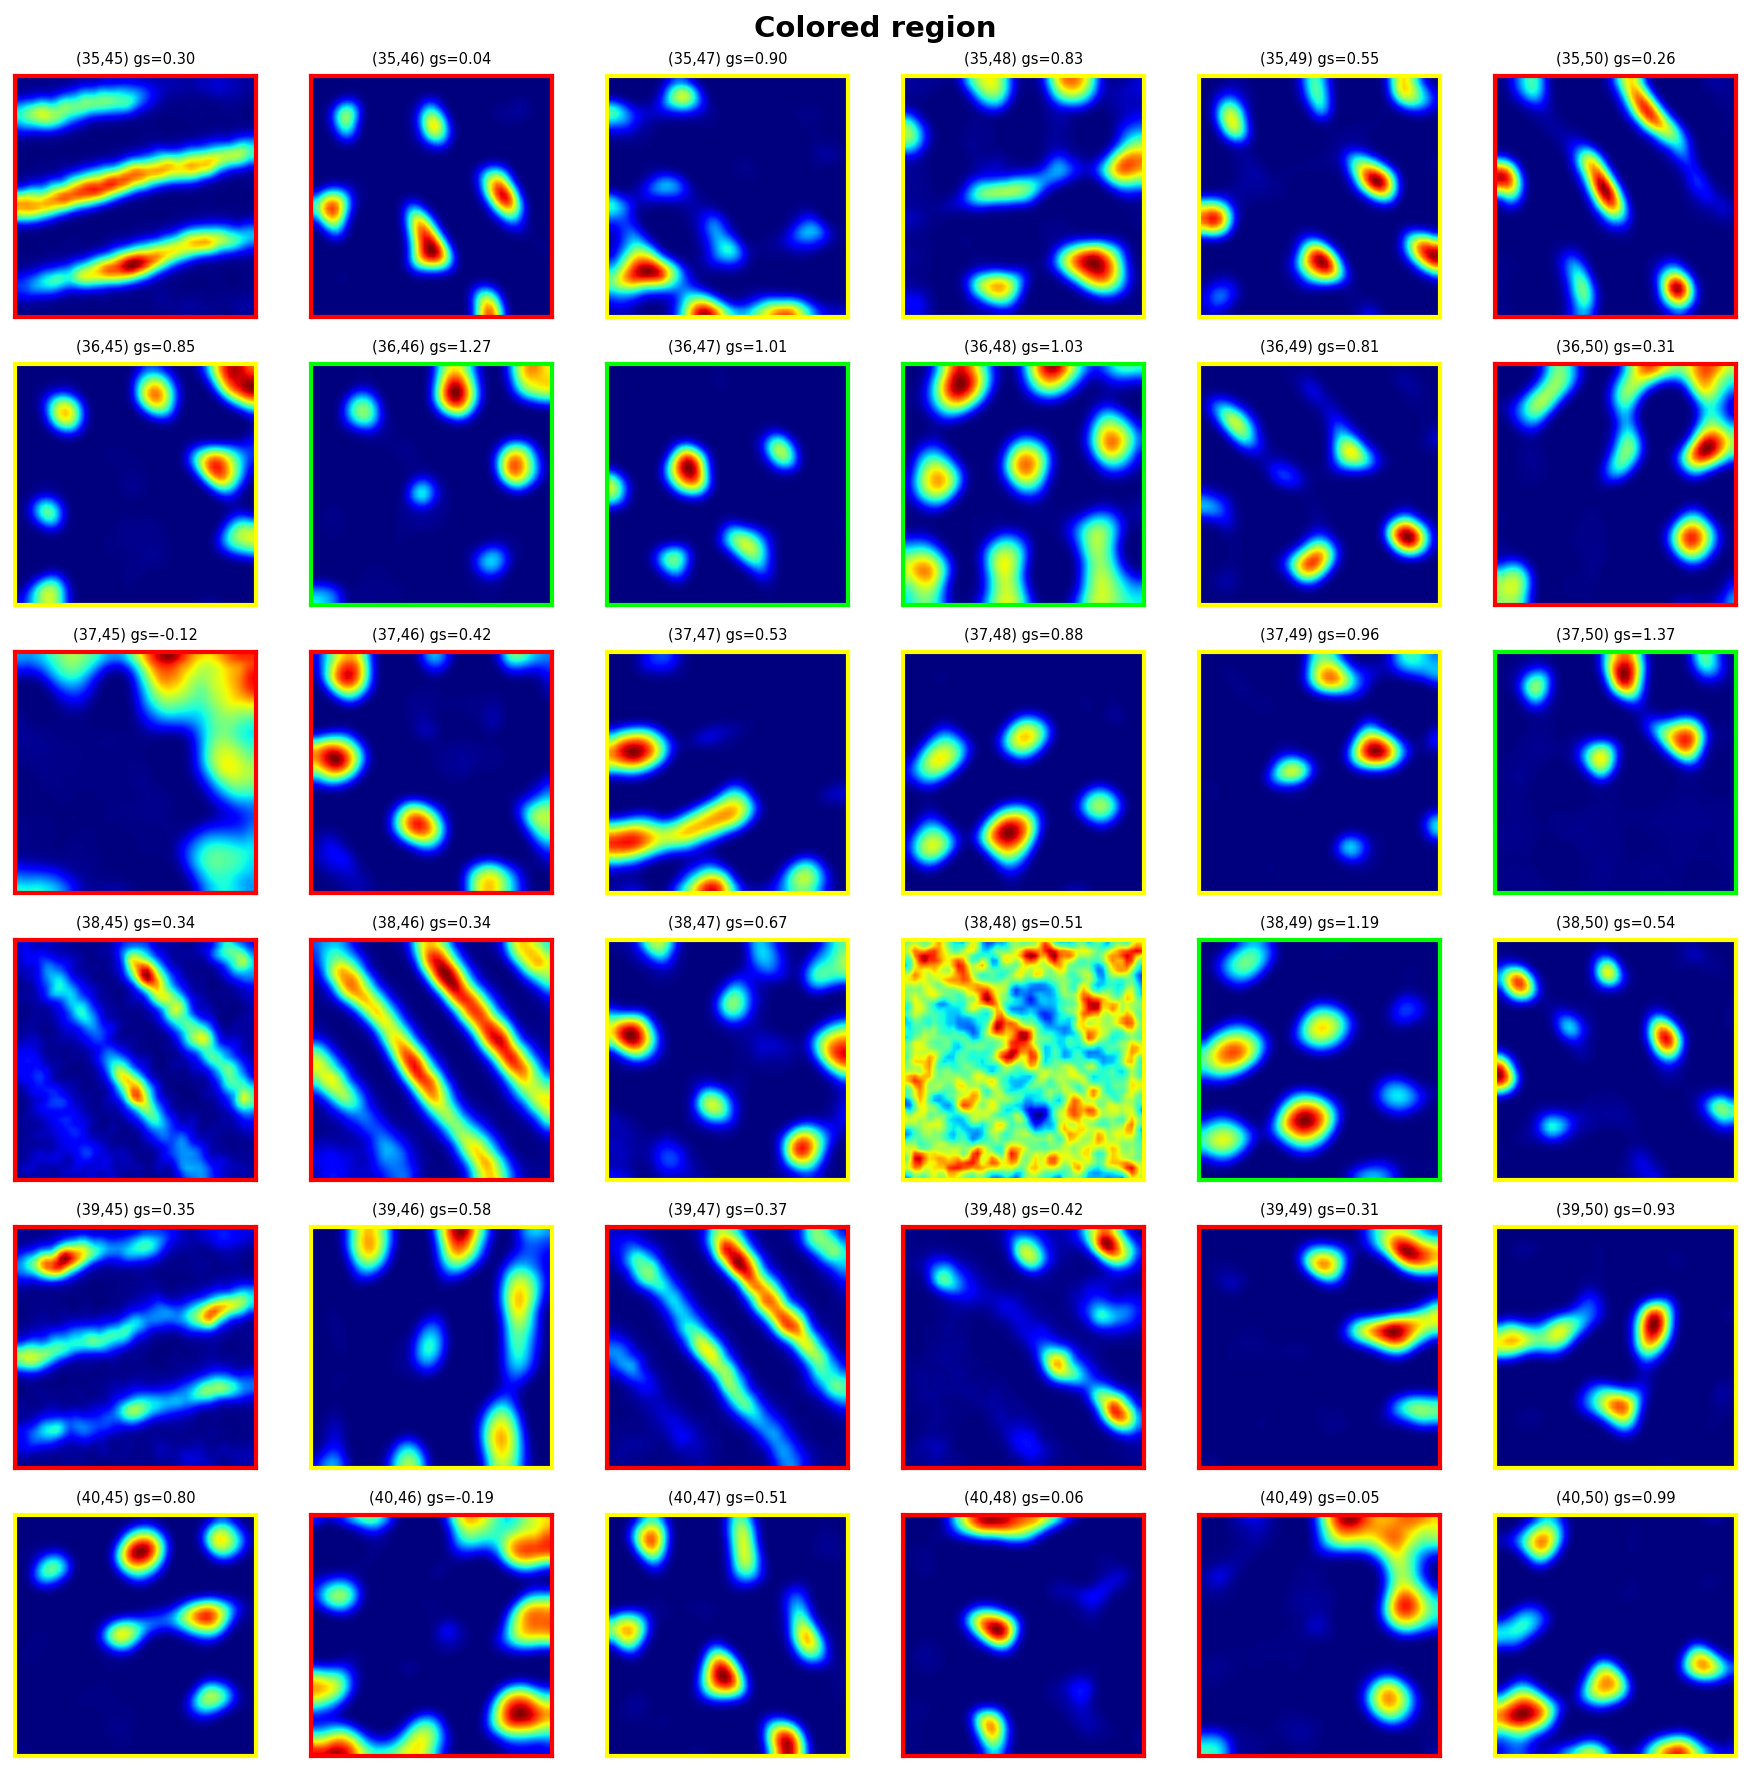

In [18]:
def plot_neuron_grid(act_array, scores_array, title, rows_cols, start_row, start_col, n, grid_size=6):
    fig, axes = plt.subplots(grid_size, grid_size, figsize=(12, 12))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    for di in range(grid_size):
        for dj in range(grid_size):
            ri = (start_row + di) % n
            ci = (start_col + dj) % n
            idx = ri * n + ci
            ax = axes[di, dj]
            rm_smooth = cv2.GaussianBlur(act_array[idx], (3, 3), sigmaX=1, sigmaY=1)
            ax.imshow(rm_smooth, cmap='jet', interpolation='bilinear')
            gs = scores_array[idx]
            ax.set_title(f'({ri},{ci}) gs={gs:.2f}', fontsize=7)
            ax.set_xticks([]); ax.set_yticks([])
            border_color = 'lime' if gs > 1.0 else ('yellow' if gs > 0.5 else 'red')
            for spine in ax.spines.values():
                spine.set_color(border_color)
                spine.set_linewidth(2)
    plt.tight_layout()
    plt.show()

# Empty region
plot_neuron_grid(act_sorted, score60_sorted,
                 'Empty region',
                 (n, n), start_row=2, start_col=2, n=n, grid_size=6)

# Colored region
plot_neuron_grid(act_sorted, score60_sorted,
                 'Colored region',
                 (n, n), start_row=35, start_col=45, n=n, grid_size=6)